# Clase 1: Análisis de Algoritmos y SGD

En esta clase implementamos y comparamos:
- Complejidad computacional de operaciones comunes
- Batch Gradient Descent (GD completo)
- Stochastic Gradient Descent con minibatches (SGD)

Todo desde cero, sin sklearn, para entender qué pasa adentro.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

## 1. Complejidad computacional

La complejidad mide cuántas operaciones realiza un algoritmo en función del tamaño de entrada `n`.
No medimos segundos (dependen del hardware), medimos **operaciones elementales**.

El tiempo asintótico `T(n)` nos dice cómo crece el costo cuando `n` es grande.

In [ ]:
# O(n)
# Crea una función que sume los elementos de una lista
def suma_lista(lista):
    total = 0
    for num in lista:
        total += num
    return total
    
# O(n^2)
#Crea una función que cuente cuántos parejas de elementos iguales hay en una lista
# ejemplo: [1, 2, 3, 2, 1] tiene 2 pares de elementos iguales (1 y 2)
def pares_iguales(lista):
    count = 0
    for i in lista: 
        for j in lista:
            if i == j:
                count += 1
    return count / 2  


def pares_iguales_2(lista):
    conteo = {} 
    for num in lista:
        if num in conteo:
            conteo[num] += 1
        else:
            conteo[num] = 1

    pares = 0
    for frecuencia in conteo.values():
        pares += frecuencia 

    return pares 



# O(1) — sin importar n
def primer_elemento(lista):
    return lista[0]   

In [8]:
# Midamos empíricamente cómo crece el tiempo con n
sizes = [100, 500, 1000, 2000, 4000, 7000 ,10000]

tiempos_on = []
tiempos_on2 = []

for n in sizes:
    lista = list(range(n))

    t0 = time.time()
    pares_iguales_2(lista)
    tiempos_on.append(time.time() - t0)

    t0 = time.time()
    pares_iguales(lista)
    tiempos_on2.append(time.time() - t0)

print(f"{'n':>6}  {'O(n) ms':>10}  {'O(n²) ms':>12}")
print("-" * 35)
for n, t1, t2 in zip(sizes, tiempos_on, tiempos_on2):
    print(f"{n:>6}  {t1*1000:>10.2f}  {t2*1000:>12.2f}")

     n     O(n) ms      O(n²) ms
-----------------------------------
   100        0.15          0.68
   500        0.43         30.87
  1000        0.34        184.69
  2000        2.37        737.43
  4000        2.50       1408.74
  7000        3.72       4852.28
 10000        6.13       9642.16


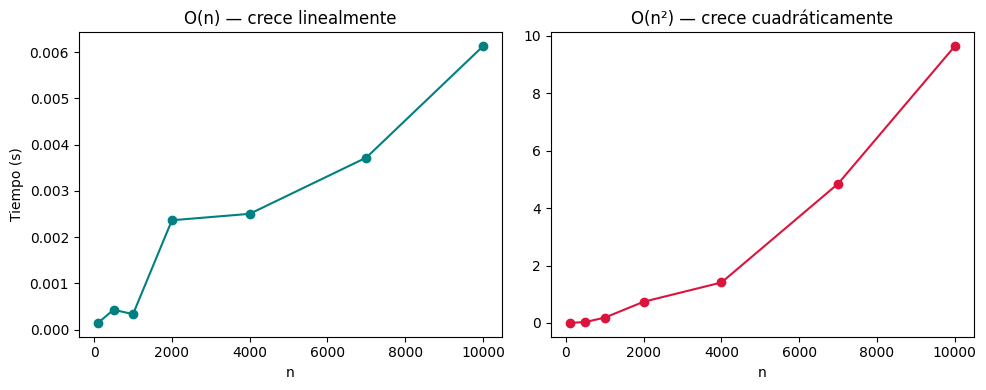

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(sizes, tiempos_on, 'o-', color='teal')
axes[0].set_title('O(n) — crece linealmente')
axes[0].set_xlabel('n'); axes[0].set_ylabel('Tiempo (s)')

axes[1].plot(sizes, tiempos_on2, 'o-', color='crimson')
axes[1].set_title('O(n²) — crece cuadráticamente')
axes[1].set_xlabel('n')

plt.tight_layout()
plt.show()

## 2. Dataset sintético

Generamos datos para un problema de regresión lineal.
La relación verdadera es: `y = 3*x1 - 2*x2 + ruido`.

In [11]:
np.random.seed(42)
n_samples = 10000
n_features = 50

X = np.random.randn(n_samples, n_features)
true_w = np.zeros(n_features)
true_w[0] = 3.0
true_w[1] = -2.0

y = X @ true_w + np.random.randn(n_samples) * 0.5

# Agregar columna de unos para el bias (w0)
X_b = np.column_stack([np.ones(n_samples), X])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (10000, 50)
y shape: (10000,)


## 3. Batch Gradient Descent

En cada iteración usa **todos los datos** para calcular el gradiente.

- Gradiente: `∇J = (2/n) · Xᵀ · (Xw − y)`
- Actualización: `w ← w − step_size · ∇L`

Complejidad por iteración: **O(n · p)** — procesa todo el dataset.

In [17]:
class BatchGD:
    def __init__(self, step_size=0.01, n_iter=100):
        self.step_size = step_size
        self.n_iter = n_iter

    def fit(self, X, y):
        #Crea la función fit que entrene el modelo usando Batch Gradient Descent
        self.w = np.zeros(X.shape[1])  
        self.losses = []

        for i in range(self.n_iter):
            y_pred = X @ self.w
            error = y_pred - y
            grad = 2 * X.T @ error / len(X)
            self.w -= self.step_size * grad
            self.losses.append(np.mean(error**2))

    def predict(self, X):
        return X @ self.w

## 4. Stochastic Gradient Descent (minibatch)

En cada iteración usa solo un **minibatch** de `batch_size` ejemplos.

- Gradiente aproximado pero mucho más rápido de calcular
- Una **época** = el modelo ha visto todos los datos una vez
- Complejidad por época: **O(n · p)** igual, pero muchas actualizaciones intermedias

In [16]:
class StochasticGD:
    def __init__(self, step_size=0.01, epochs=10, batch_size=200):
        self.step_size = step_size
        self.epochs = epochs
        self.batch_size = batch_size

    def fit(self, X, y):
        n, p = X.shape
        self.w = np.zeros(p)
        self.losses = []

        for epoch in range(self.epochs):
        
            idx = np.random.permutation(n)
            X_shuf, y_shuf = X[idx], y[idx]
            
            for i in range(0, n, self.batch_size):
                X_b = X_shuf[i : i + self.batch_size]
                y_b = y_shuf[i : i + self.batch_size]

                pred = X_b @ self.w
                error = pred - y_b
                grad = (2 / len(X_b)) * X_b.T @ error    # solo batch_size filas
                self.w -= self.step_size * grad

            # Guardamos el error al final de cada época
            epoch_pred = X @ self.w
            self.losses.append(np.mean((epoch_pred - y)**2))

    def predict(self, X):
        return X @ self.w

## 5. Comparación empírica

In [24]:
# Entrenamos ambos y medimos tiempo
batch_model = BatchGD(step_size=0.01, n_iter=100)
t0 = time.time()
batch_model.fit(X_b, y)
t_batch = time.time() - t0

sgd_model = StochasticGD(step_size=0.01, epochs=100, batch_size=200)
t0 = time.time()
sgd_model.fit(X_b, y)
t_sgd = time.time() - t0

print(f"Batch GD — tiempo: {t_batch:.3f}s | MSE final: {batch_model.losses[-1]:.4f}")
print(f"SGD      — tiempo: {t_sgd:.3f}s  | MSE final: {sgd_model.losses[-1]:.4f}")

Batch GD — tiempo: 1.935s | MSE final: 0.4859
SGD      — tiempo: 2.563s  | MSE final: 0.2516


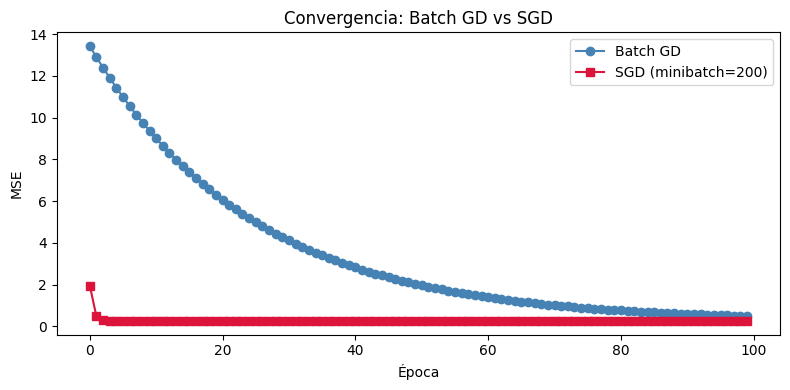

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(batch_model.losses, 'o-', label='Batch GD', color='steelblue')
plt.plot(sgd_model.losses, 's-', label='SGD (minibatch=200)', color='crimson')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Convergencia: Batch GD vs SGD')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Efecto del batch_size

¿Cómo cambia la convergencia según el tamaño del batch?
- Batch pequeño: más ruido, más actualizaciones, puede escapar mínimos locales
- Batch grande: más estable pero más costo por iteración

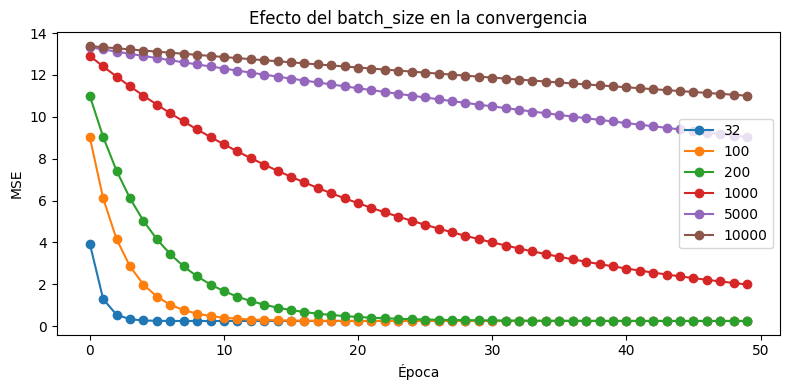

In [34]:
batch_sizes = [32, 100, 200, 1000, 5000, len(X_b)]    
results = {}

for bs in batch_sizes:
    sgd_model = StochasticGD(step_size=0.001, epochs=50, batch_size=bs)
    sgd_model.fit(X_b, y)
    results[bs] = sgd_model.losses

plt.figure(figsize=(8, 4))
for label, losses in results.items():
    plt.plot(losses, 'o-', label=label)
plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Efecto del batch_size en la convergencia')
plt.legend()
plt.tight_layout()
plt.show()

## 7. ¿Qué aprendió el modelo?

Verificamos que los pesos aprendidos se acercan a los valores reales `[3, -2, 0, 0, ...]`.

In [32]:
# Comparar los primeros 5 pesos aprendidos vs los reales
# (índice 0 = bias, índices 1-5 = primeras features)
print("Feature  | Peso real | Peso aprendido (SGD)")
print("-" * 40)
for i in range(6):
    real = true_w[i-1] if i > 0 else 0.0
    aprendido = sgd_model.w[i]
    print(f"  w{i:<4}  |   {real:>6.2f}  |   {aprendido:>6.3f}")

Feature  | Peso real | Peso aprendido (SGD)
----------------------------------------
  w0     |     0.00  |    0.019
  w1     |     3.00  |    1.917
  w2     |    -2.00  |   -1.285
  w3     |     0.00  |    0.005
  w4     |     0.00  |   -0.007
  w5     |     0.00  |    0.010


## Conclusiones

- **O(n)** es siempre preferible a **O(n²)** en datasets grandes
- **Batch GD** calcula gradientes exactos pero escala mal con `n`
- **SGD con minibatches** es la solución estándar en ML: rápido, eficiente en memoria
- Un `batch_size` de 100-200 suele dar buen equilibrio velocidad/estabilidad
- Con suficientes épocas, SGD converge a resultados comparables a Batch GD